# 01 - Exploration des données de location (Sénégal)

Ce notebook sert uniquement à **explorer, comprendre et justifier** les choix de nettoyage.
Il ne contient **aucune logique de production** : une fois les décisions prises ici,
elles seront implémentées sous forme de fonctions typées et testées dans
`src/senegal_rental_price/data/preprocessing.py`.

Données issues du scraping de NeoBien (`data/raw/locations.csv`), usage strictement académique.

## 1. Chargement des données brutes

In [ ]:
import pandas as pd

df = pd.read_csv("data/raw/locations.csv", sep=";", encoding="utf-8-sig")
print(f"Nombre d'annonces brutes : {len(df)}")
df.head()

Nombre d'annonces brutes : 166


,id,ville,quartier,type_bien,surface_m2,surface_estimee,nb_pieces,nb_chambres,meuble,equipements,prix_loyer_mensuel,titre,adresse,date_publication
0,6a3a5671468a708472e39b6a,Dakar,Mermoz - Sacré-Cœur,appartement,67.2,True,3.0,2.0,False,piscine|gardiennage|parking|salle_de_sport,900000,Bel appartement neuf à Mermoz,NaN,2026-06-23T09:48:33.330Z
1,6a3a54fd468a708472e39b5d,Dakar,Fann - Point E,appartement,64.2,True,3.0,2.0,False,climatisation|gardiennage|parking|meuble,1150000,À LOUER - APPARTEMENT MEUBLÉ HAUT STANDING AU ...,NaN,2026-06-23T09:42:21.990Z
2,6a3a5453468a708472e39b56,Dakar,Almadies,appartement,73.4,True,3.0,2.0,False,piscine|climatisation|gardiennage|meuble,900000,À LOUER – APPARTEMENT HAUT STANDING AUX ALMADIES,NaN,2026-06-23T09:39:31.089Z
3,6a2c75214e70616a9aaeeaea,Diakhirate,Nouvel Horizon,appartement,75.3,True,4.0,3.0,NaN,NaN,170000,Appartement à louer,NaN,2026-06-12T21:07:45.550Z
4,6a2066514f9b3394cf0b3cce,Dakar,Almadies,appartement,47.6,True,NaN,NaN,False,piscine|gardiennage|parking|salle_de_sport,1300000,À LOUER – Appartement de standing 4ᵉ étage aux...,NaN,2026-06-03T17:37:21.774Z


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  166 non-null    str    
 1   ville               166 non-null    str    
 2   quartier            166 non-null    str    
 3   type_bien           166 non-null    str    
 4   surface_m2          166 non-null    float64
 5   surface_estimee     166 non-null    bool   
 6   nb_pieces           160 non-null    float64
 7   nb_chambres         159 non-null    float64
 8   meuble              164 non-null    object 
 9   equipements         155 non-null    str    
 10  prix_loyer_mensuel  166 non-null    int64  
 11  titre               166 non-null    str    
 12  adresse             3 non-null      str    
 13  date_publication    166 non-null    str    
dtypes: bool(1), float64(3), int64(1), object(1), str(8)
memory usage: 17.2+ KB


## 2. Valeurs manquantes

In [3]:
df.isna().sum().sort_values(ascending=False)

adresse               163
equipements            11
nb_chambres             7
nb_pieces               6
meuble                  2
id                      0
surface_estimee         0
surface_m2              0
type_bien               0
quartier                0
ville                   0
prix_loyer_mensuel      0
titre                   0
date_publication        0
dtype: int64

**Décision (à documenter/adapter selon ce que tu observes) :**
- `nb_pieces` / `nb_chambres` manquants → imputation par la médiane, groupée par `type_bien`.
- `quartier` manquant → catégorie `"Non renseigné"` plutôt que suppression de la ligne.
- Lignes avec `prix_loyer_mensuel` manquant ou nul → déjà exclues au scraping.

## 3. Cohérence de la variable `ville`

In [4]:
df["ville"].value_counts()

ville
Thiès         94
Dakar         71
Diakhirate     1
Name: count, dtype: int64

On vérifie ici si certaines valeurs de `ville` sont incohérentes
(ex. un nom de quartier ou de localité mal classé au lieu d'une vraie ville/région).
Repère les valeurs peu fréquentes ou hors de la liste attendue
(Dakar, Thiès, Saint-Louis, Mbour, Saly, Ziguinchor...) et décide : correction manuelle,
regroupement, ou suppression de la ligne (à justifier).

## 4. Surfaces : réelles vs estimées

In [5]:
df["surface_estimee"].value_counts(normalize=True) * 100

surface_estimee
True     70.481928
False    29.518072
Name: proportion, dtype: float64

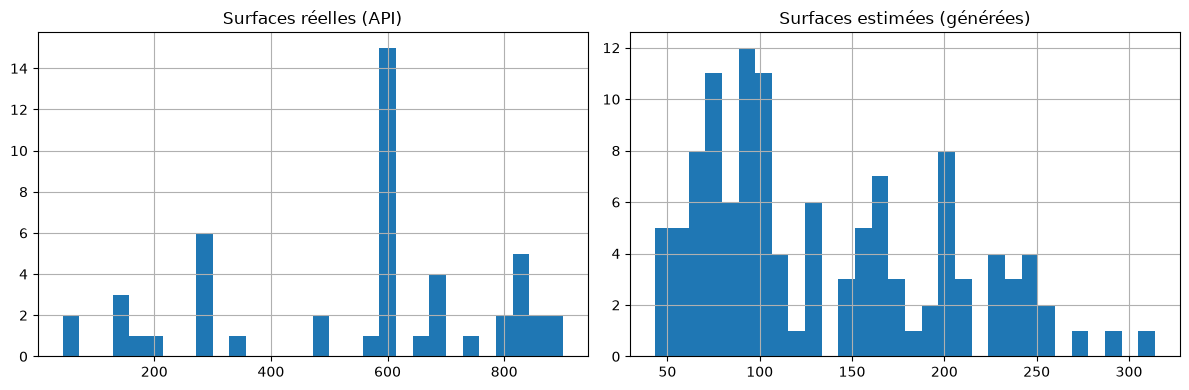

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[df["surface_estimee"] == False]["surface_m2"].hist(ax=ax[0], bins=30)
ax[0].set_title("Surfaces réelles (API)")
df[df["surface_estimee"] == True]["surface_m2"].hist(ax=ax[1], bins=30)
ax[1].set_title("Surfaces estimées (générées)")
plt.tight_layout()
plt.show()

**À commenter :** est-ce que la distribution des surfaces estimées est cohérente
avec celle des surfaces réelles ? Si les deux distributions sont trop différentes,
il faudra ajuster la formule de génération synthétique (documentée dans `data/README.md`).

## 5. Distribution du prix de location (variable cible)

In [7]:
df["prix_loyer_mensuel"].describe()

count    1.660000e+02
mean     1.243672e+06
std      1.289828e+06
min      3.500000e+03
25%      6.500000e+05
50%      1.000000e+06
75%      1.500000e+06
max      1.500000e+07
Name: prix_loyer_mensuel, dtype: float64

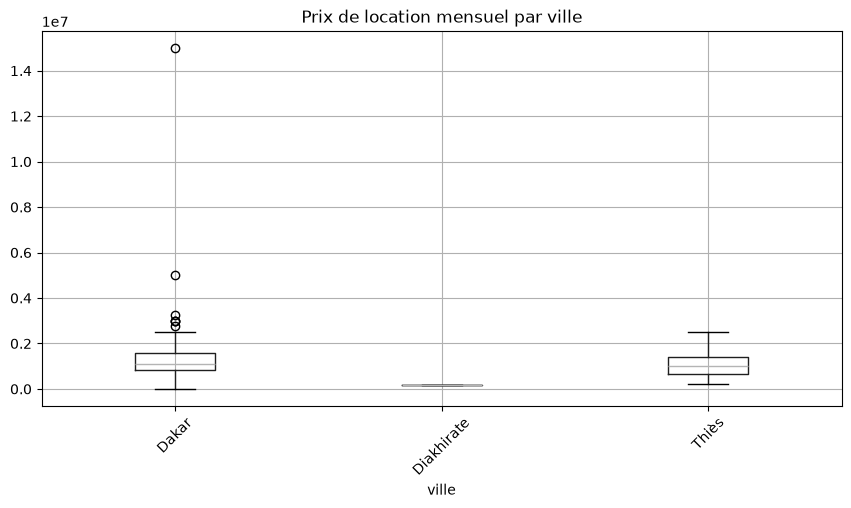

In [8]:
df.boxplot(column="prix_loyer_mensuel", by="ville", figsize=(10, 5), rot=45)
plt.suptitle("")
plt.title("Prix de location mensuel par ville")
plt.show()

La distribution du prix est très étalée (écart-type ≈ moyenne), avec deux valeurs extrêmes clairement identifiées : un minimum de 3 500 FCFA/mois (probable erreur de saisie côté source — aucun logement réel à ce tarif) et un maximum de 15 000 000 FCFA/mois, correspondant à l'annonce d'un immeuble entier destiné à un usage bureaux/commerce, non comparable à une location résidentielle. Ces deux extrêmes ont été exclus via un filtre [20 000 ; 5 000 000] FCFA dans preprocessing.py (cf. clean_prix()).

## 6. Prix au m² par quartier (Dakar)

In [9]:
dakar = df[df["ville"] == "Dakar"].copy()
dakar["prix_m2"] = dakar["prix_loyer_mensuel"] / dakar["surface_m2"]
dakar.groupby("quartier")["prix_m2"].median().sort_values(ascending=False).head(15)

quartier
Fann - Point E         28766.211966
Fann                   19230.769231
Mermoz                 14526.284717
Point E                12348.484848
Almadies               12063.907774
Ouakam                 11444.122429
Mermoz - Sacré-Cœur     7850.274725
Mamelles                7322.740501
Grand Dakar             6578.947368
Ngor                    5647.058824
Plateau                 5405.405405
Yoff                    5405.405405
Cité Keur Gorgui        5403.999454
Toubab Dialaw           3502.069405
Lac Rose                1333.333333
Name: prix_m2, dtype: float64

Le classement obtenu est partiellement surprenant : Almadies (12 063 FCFA/m²) et surtout Plateau (5 405 FCFA/m²) ressortent plus bas qu'attendu au vu de leur réputation de quartiers premium, tandis que "Fann - Point E" arrive largement en tête (28 766 FCFA/m²). Deux explications probables plutôt qu'une réalité de marché : (1) l'échantillon par quartier est très réduit (parfois 1 à 3 annonces), donc sensible à un ou deux biens atypiques ; (2) environ 70 % des surfaces sont estimées et non mesurées (surface_estimee=True), ce qui introduit du bruit direct dans le ratio prix/m². Ce classement doit donc être interprété avec prudence et n'est pas utilisé tel quel comme feature dans le modèle.

## 7. Décisions de nettoyage retenues (résumé)

À remplir une fois l'exploration terminée, par exemple :

1. Exclusion des lignes avec `ville` hors de la liste autorisée (X lignes concernées).
2. Imputation de `nb_pieces`/`nb_chambres` par la médiane.
3. Conservation de `surface_estimee` comme variable explicative à part entière
   (ou à titre indicatif seulement, exclue du modèle - à trancher).
4. Exclusion des annonces avec un prix aberrant (> Z FCFA/mois), probables biens commerciaux.

Ces règles seront implémentées et testées dans `src/senegal_rental_price/data/preprocessing.py`.